# Astronomy Application

In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type = 'S2'
manifold = get_manifold(manifold_type)

## import data, visualise

In [2]:
df = pd.read_csv('data/BATSE_4B.txt', header=None, sep='\s+', encoding='utf-8')

# Assume column 5 = RA, column 6 = Dec (in degrees)
ra = df[5].values
dec = df[6].values
phi = np.deg2rad(ra)           # longitude
theta = np.pi/2 - np.deg2rad(dec)  # colatitude
X_sph = np.column_stack([theta, phi])
X = manifold.spherical_to_extrinsic(X_sph)

# sigma2 = np.mean(np.power(df[9].values * np.pi/180.,2))
sigma2 = 3.046*1e-2
print('Average angular variance (in rad^2): ', sigma2)
if False: S2scatter(X, ax, color='C0', alpha=0.25)  # Changed axs[0] to axs[1]


Average angular variance (in rad^2):  0.030459999999999997


Folds: 100%|██████████| 5/5 [00:37<00:00,  7.56s/it]

23 0.007111473780185294


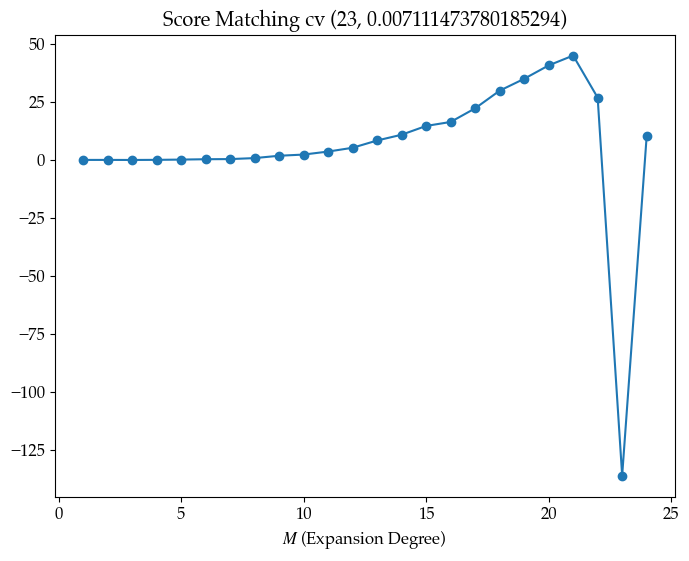

In [ ]:
M_grid=np.arange(1, 25)
rho_grid = None 
criterion = 'AIC'
# params, scores = scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=50, return_scores = True, random_state=42, rho_percentile = 1.5)
params, scores = scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=5, return_scores = True, random_state=42, rho_percentile = 1)

if True: plot_density_cv_scores(scores[criterion], M_grid, rho_grid, title=f"Score Matching cv {params[criterion]}")
M, rho = params[criterion]
print(M,rho)


In [3]:
M =23
rho = 0.01

# Density estimation

In [4]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res = 80
X_grid, grid_theta, grid_phi, = S2grid(res)
X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)
hat_score = hat_grad_f / np.maximum(hat_f[:, np.newaxis], rho)

## Empirical Bayes denoising

In [5]:
delta = denoiser('S2', X, M, rho, sigma2, X)

# Plot results

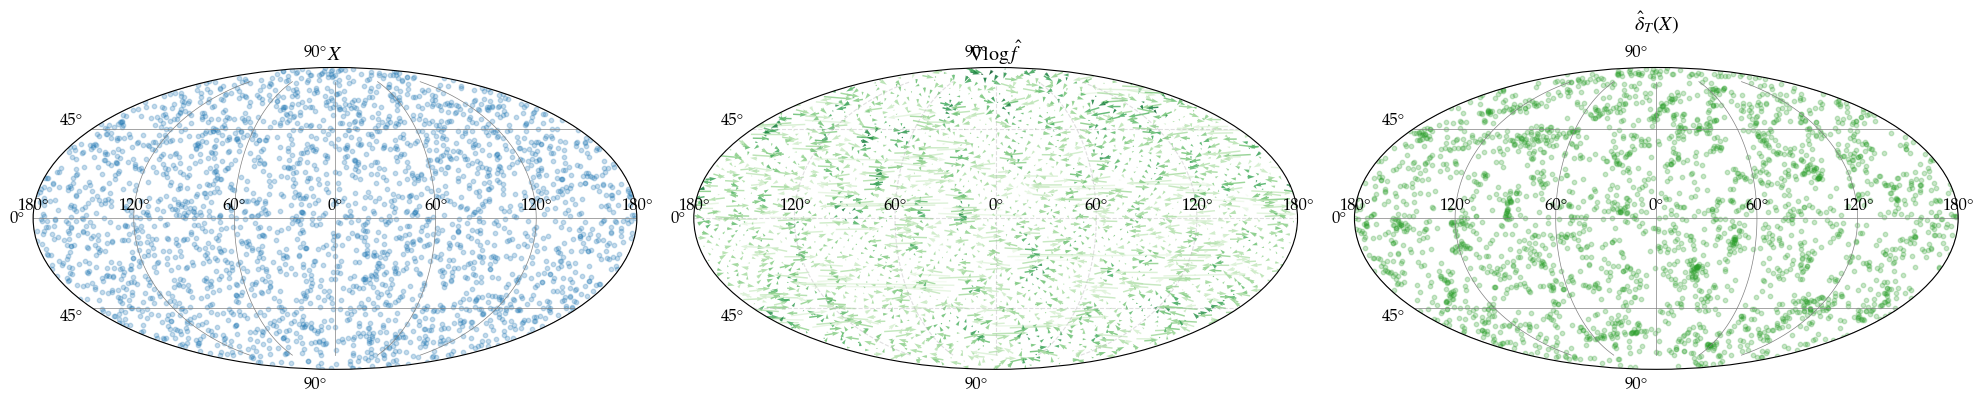

In [8]:

fig, axs = plt.subplots(1, 3, figsize=(20, 6), 
                        subplot_kw={'projection': 'mollweide'}
                        )

# left plot: X
axs[0].grid(True, color='gray', lw=0.5)
axs[0].set_title('$X$')
S2scatter(X, ax=axs[0], color='C0', alpha=0.25, s=10)

# right plot: $\hat{\delta}_T(X_i)$
axs[2].set_title('$\\hat{\\delta}_T(X)$', y =1.1)
S2scatter(delta, ax=axs[2], color='C2', alpha=0.25, s=10)


# center plot: $\nabla \log \hat{f}$
_X_grid, _hat_f, _hat_grad_f = density_estimate('S2', X, M, S2grid_fib(50)[0])
_score = _hat_grad_f/np.maximum(_hat_f, rho)[:, None]
vals_to_plot =  {   'gradient': {'vals': _hat_grad_f, 'cmap' : 'Greys', 'title' : r'$\nabla \hat f$' },
                    'score': {'vals': _score, 'cmap' : 'Greens', 'title' : r'$\nabla \log \hat f$' }}
WHICH = 'score' # 'gradient' or 'score'

S2plot_quiver(_X_grid , vals_to_plot[WHICH]['vals'], skip = 1,
              figax= (fig,axs[1]), scale=50, cmap = vals_to_plot[WHICH]['cmap'], cvals = _hat_f)
axs[1].set_title(vals_to_plot[WHICH]['title'])

for ax in axs.flatten():   
    ax.set_xticks(np.linspace(-np.pi, np.pi, 7))
    ax.set_xticklabels(['180°', '120°', '60°', '0°', '60°', '120°', '180°'])
    ax.set_yticks(np.linspace(-np.pi/2, np.pi/2, 5))
    ax.set_yticklabels(['90°', '45°', '0°', '45°', '90°'])

plt.tight_layout()
plt.savefig('fig/astro.png', bbox_inches='tight')
plt.show()



----

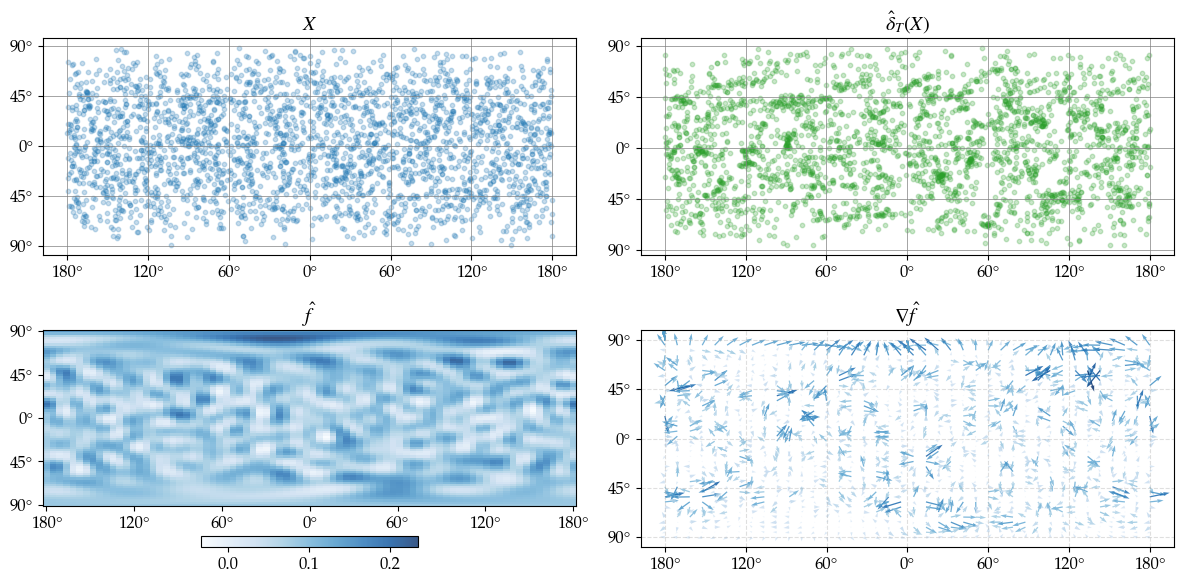

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(12, 6), 
                        # subplot_kw={'projection': 'mollweide'}
                        )

# Top-left plot: X
axs[0, 0].grid(True, color='gray', lw=0.5)
axs[0, 0].set_title('$X$')
S2scatter(X, ax=axs[0, 0], color='C0', alpha=0.25, s=10)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0, 1].set_title('$\\hat{\\delta}_T(X)$')
S2scatter(delta, ax=axs[0, 1], color='C2', alpha=0.25, s=10)

# Bottom-left plot: $\hat{f}$
axs[1,0].set_title(r'$\hat f$')
im_f = axs[1,0].pcolormesh((grid_phi - np.pi), (np.pi/2 - grid_theta), # in mollwide!
                        hat_f.reshape(res, res),
                        alpha=0.8,shading='auto',cmap='Blues')
fig.colorbar(im_f, ax=axs[1,0], orientation='horizontal', fraction=0.05, pad=0.14)

# Bottom-right plot: $\nabla \log \hat{f}$ 

_X_grid = S2grid(40)[0]; _X_grid, _hat_f, _hat_grad_f = density_estimate('S2', X, M, _X_grid)
_score = np.zeros_like(_hat_grad_f)
np.divide(
    _hat_grad_f,
    np.maximum(_hat_f, rho)[:, None],
    out=_score,
    where=_hat_f[:, None] >= rho + 1e-1
)

vals_to_plot =  {   'gradient': {'vals': _hat_grad_f, 'cmap' : 'Blues', 'title' : r'$\nabla \hat f$' },
                    'score': {'vals': _score, 'cmap' : 'Greens', 'title' : r'$\nabla \log \hat f$' }}
WHICH = 'gradient' # 'gradient' or 'score'

S2plot_quiver(_X_grid , vals_to_plot[WHICH]['vals'], 
              figax= (fig,axs[1,1]), scale=5, cmap = vals_to_plot[WHICH]['cmap'])
axs[1,1].set_title(vals_to_plot[WHICH]['title'])

for ax in axs.flatten():   
    ax.set_xticks(np.linspace(-np.pi, np.pi, 7))
    ax.set_xticklabels(['180°', '120°', '60°', '0°', '60°', '120°', '180°'])
    ax.set_yticks(np.linspace(-np.pi/2, np.pi/2, 5))
    ax.set_yticklabels(['90°', '45°', '0°', '45°', '90°'])

plt.tight_layout()
plt.savefig('fig/astro.png', bbox_inches='tight')
plt.show()



In [18]:

_X_grid = S2grid(100)[0]; _X_grid, _hat_f, _hat_grad_f = density_estimate('S2', X, M, _X_grid)


_score = _hat_grad_f/np.maximum(_hat_f, rho)[:, None]
vals_to_plot =  {   'gradient': {'vals': _hat_grad_f, 'cmap' : 'Greys', 'title' : r'$\nabla \hat f$' },
                    'score': {'vals': _score, 'cmap' : 'Greens', 'title' : r'$\nabla \log \hat f$' }}
WHICH = 'score' # 'gradient' or 'score'


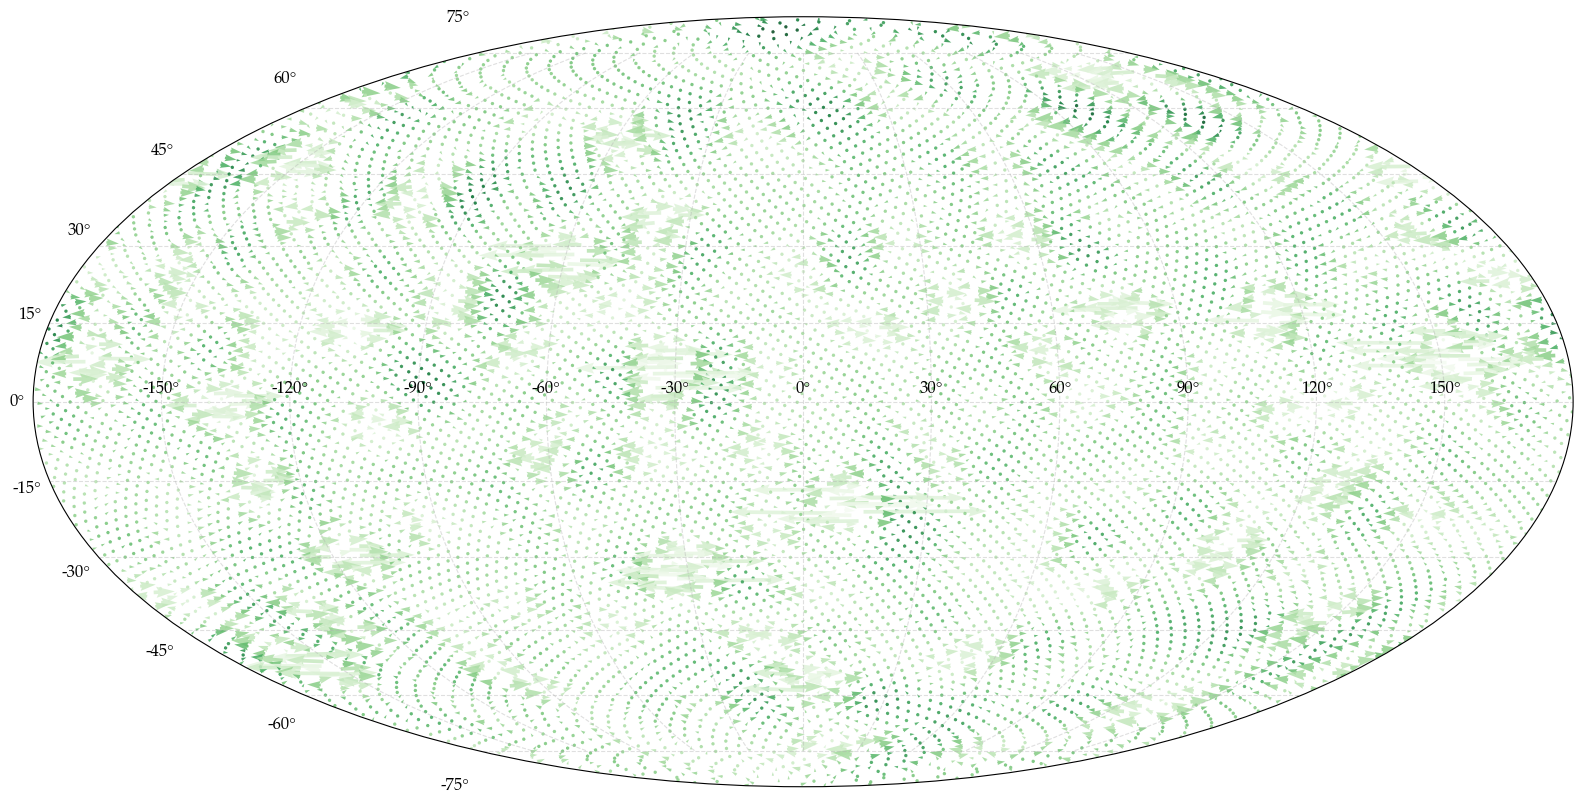

In [20]:
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={'projection': 'mollweide'})
S2plot_quiver(_X_grid , vals_to_plot[WHICH]['vals'], skip = 1,
              figax= (fig,ax), scale=200, cmap = vals_to_plot[WHICH]['cmap'], cvals = _hat_f)

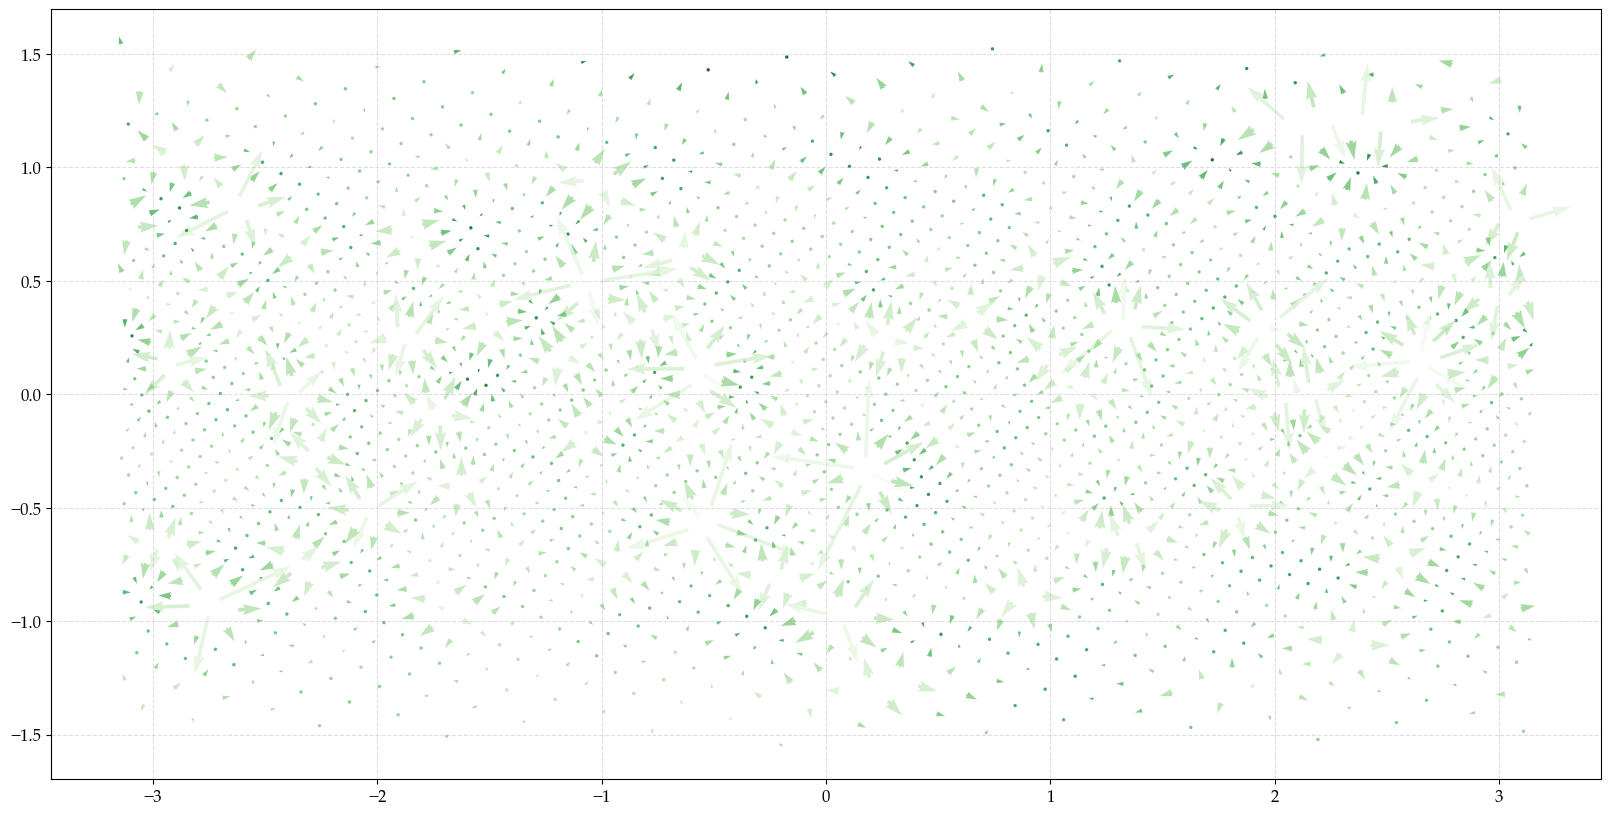

In [16]:
WHICH = 'score' # 'gradient' or 'score'
fig, ax = plt.subplots(figsize=(20, 10))
S2plot_quiver(_X_grid , vals_to_plot[WHICH]['vals'], skip = 1,
              figax= (fig,ax), scale=250, cmap = vals_to_plot[WHICH]['cmap'], cvals = _hat_f)